# 05 - Fine-Tuning on Distorted Data (Part 4)



**1. Core Scope & Tasks**


Task Scope: Applies only to learning-based models—Object Detection (YOLO) and Semantic Segmentation (SegFormer). Classical non-learned methods (ORB feature matching, optical flow) are excluded because they lack trainable weights.


Ground-Truth Labels: Reuses the original clean GT labels for distorted images, as distortions alter pixels but not content.


**2. Distortion-Aware Fine-Tuning Strategy**


Blended Training Set (Phase A): Trains one shared distortion-aware model per task using a materialized dataset that blends all 3 distortion types across all 5 severity levels.


Evaluation (Phase B): The single fine-tuned checkpoint is evaluated against each distortion's max-severity test set individually to generate comparative results per distortion.


Design Goal: Prioritizes real-world model robustness across varied degradations rather than training a single-distortion/single-severity model.


**3. Clean-Control Ablation Study**


Control Setup: Alongside the distortion-aware model, a second clean-control model is fine-tuned strictly on undistorted clean images using identical starting checkpoints, hyperparameters, and epoch counts.


Purpose: Determines whether accuracy gains stem specifically from exposure to distorted images or simply from extra training epochs on clean data.



In [1]:
import os
import sys

IN_COLAB = "google.colab" in str(get_ipython())
REPO_URL = "https://github.com/Shir-Siman-Tov/Image-Processing-Project.git"
REPO_DIR = "/content/Image-Processing-Project"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
    else:
        # Runtime already had this repo cloned from an earlier cell run in this
        # session - pull so we don't keep running against a stale checkout.
        get_ipython().system(f"git -C {REPO_DIR} pull")
    os.chdir(REPO_DIR)
    get_ipython().system("pip install -q -e .")
    get_ipython().system("pip install -q -r requirements.txt")

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

from ipproj import config
from ipproj.datasets import kitti, kitti_flow, kitti_yolo_format
from ipproj.datasets.kitti import read_image
from ipproj.datasets.materialize import materialize_transformed
from ipproj.tasks import object_detection, semantic_segmentation
from ipproj.distortions import REGISTRY as DISTORTIONS
from ipproj.viz.plotting import (
    plot_detection_boxes, plot_grouped_bar_per_class, plot_metric_vs_intensity, plot_segmentation_mask, save_figure,
)
from ipproj.reporting import save_results_csv

detection_splits = kitti.load_object_detection_subset()
segmentation_splits = kitti.load_semantic_segmentation_subset()

checkpoint_path = (config.CHECKPOINT_ROOT / "yolo_clean_baseline_path.txt").read_text().strip()

distortion_results = pd.read_csv(config.RESULTS_ROOT / "03_distortions.csv")
restoration_df = pd.read_csv(config.RESULTS_ROOT / "04_restoration.csv")
clean_baseline = pd.read_csv(config.RESULTS_ROOT / "02_clean_baseline.csv").set_index("metric")["value"]

## Phase A: build the blended (all distortions x all severities) training mix, then fine-tune the distortion-aware model and its clean-control counterpart per task (split into one cell per model/run below)

In [3]:
# --- Build the blended training mix: every distortion x every severity level ---
blended_train_detection = []
blended_val_detection = []
blended_train_segmentation = []
blended_val_segmentation = []

for name, module in DISTORTIONS.items():
    for level in range(len(module.LEVELS)):
        distort_fn = lambda img, m=module, l=level: m.distort(img, l)
        prefix = f"{name}_lvl{level}_"

        # Written to SCRATCH_ROOT (Colab-local disk, not Drive) rather than
        # DISTORTED_ROOT - these ~8,900 blended images are deterministically
        # regenerable from the already-downloaded clean images + this pure
        # distortion function, so they don't need Drive's durability, only
        # the speed of a local disk (Drive-mounted many-small-file I/O was
        # the actual bottleneck here, easily tens of minutes for this loop).
        blended_train_detection += materialize_transformed(
            detection_splits["train"], distort_fn,
            config.SCRATCH_ROOT / "blended" / name / f"train_detection_lvl{level}",
            name_prefix=prefix,
        )
        blended_val_detection += materialize_transformed(
            detection_splits["val"], distort_fn,
            config.SCRATCH_ROOT / "blended" / name / f"val_detection_lvl{level}",
            name_prefix=prefix,
        )
        blended_train_segmentation += materialize_transformed(
            segmentation_splits["train"], distort_fn,
            config.SCRATCH_ROOT / "blended" / name / f"train_segmentation_lvl{level}",
            name_prefix=prefix,
        )
        blended_val_segmentation += materialize_transformed(
            segmentation_splits["val"], distort_fn,
            config.SCRATCH_ROOT / "blended" / name / f"val_segmentation_lvl{level}",
            name_prefix=prefix,
        )

materializing train_detection_lvl0:   0%|          | 0/350 [00:00<?, ?img/s]

materializing val_detection_lvl0:   0%|          | 0/75 [00:00<?, ?img/s]

materializing train_segmentation_lvl0:   0%|          | 0/140 [00:00<?, ?img/s]

materializing val_segmentation_lvl0:   0%|          | 0/30 [00:00<?, ?img/s]

materializing train_detection_lvl1:   0%|          | 0/350 [00:00<?, ?img/s]

...

materializing val_segmentation_lvl3:   0%|          | 0/30 [00:00<?, ?img/s]

materializing train_detection_lvl4:   0%|          | 0/350 [00:00<?, ?img/s]

materializing val_detection_lvl4:   0%|          | 0/75 [00:00<?, ?img/s]

materializing train_segmentation_lvl4:   0%|          | 0/140 [00:00<?, ?img/s]

materializing val_segmentation_lvl4:   0%|          | 0/30 [00:00<?, ?img/s]

### YOLO: distortion-aware (blended) fine-tune

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/yolo_training_curve_blended.png')

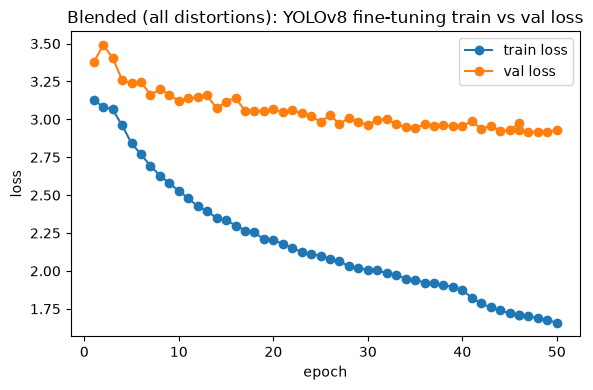

In [ ]:
# --- Fine-tune the distortion-aware YOLO model on the blend (continues the clean-adapted checkpoint from 02) ---

# fine_tune() reads them, even after a fresh runtime wiped /content.
blended_data_yaml = kitti_yolo_format.build_yolo_dataset(
    {"train": blended_train_detection, "val": blended_val_detection, "test": detection_splits["test"]},
    output_dir=config.SCRATCH_ROOT / "yolo_format_distorted" / "blended",
)
blended_checkpoint = object_detection.fine_tune(blended_data_yaml, "finetuned_blended", start_weights=checkpoint_path)
finetuned_yolo = YOLO(blended_checkpoint)

training_curve = object_detection.load_training_curve(blended_checkpoint)
fig = plot_metric_vs_intensity(
    training_curve["epoch"],
    {"train loss": training_curve["train_loss"], "val loss": training_curve["val_loss"]},
    xlabel="epoch", ylabel="loss", title="Blended (all distortions): YOLOv8 fine-tuning train vs val loss",
)
save_figure(fig, "05_finetuning_distorted/yolo_training_curve_blended.png")

The training loss drops smoothly from $\approx 3.12$ down to $\approx 1.66$, confirming that the model successfully optimizes its weights across the mix of all distortion types and severity levels.

Validation loss quickly improves from $\approx 3.38$ and plateaus around $\approx 2.92\text{--}2.95$ after epoch 20. The validation loss remains stable rather than rising, indicating good generalization to noisy validation samples without significant overfitting.


### YOLO: clean-control fine-tune

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/yolo_training_curve_clean_control.png')

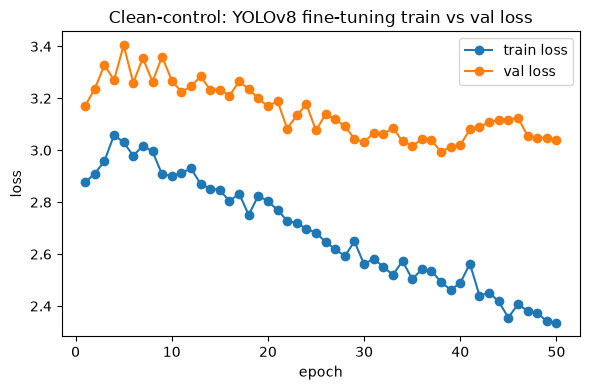

In [ ]:
# --- Clean-control counterpart: same checkpoint, same hyperparameters, same epoch
# count, but continues on the plain clean train/val splits (no distortion). Passed

clean_control_data_yaml = kitti_yolo_format.build_yolo_dataset(
    {"train": detection_splits["train"], "val": detection_splits["val"], "test": detection_splits["test"]},
    output_dir=config.SCRATCH_ROOT / "yolo_format_distorted" / "clean_control",
)
clean_control_checkpoint = object_detection.fine_tune(
    clean_control_data_yaml, "finetuned_clean_control", start_weights=checkpoint_path
)
finetuned_yolo_clean_control = YOLO(clean_control_checkpoint)

clean_control_training_curve = object_detection.load_training_curve(clean_control_checkpoint)
fig = plot_metric_vs_intensity(
    clean_control_training_curve["epoch"],
    {"train loss": clean_control_training_curve["train_loss"], "val loss": clean_control_training_curve["val_loss"]},
    xlabel="epoch", ylabel="loss", title="Clean-control: YOLOv8 fine-tuning train vs val loss",
)
save_figure(fig, "05_finetuning_distorted/yolo_training_curve_clean_control.png")

Slower, Smooth Optimization: The training loss decreases steadily from $\approx 2.88$ down to $\approx 2.33$. Compared to the blended distortion run, loss reduction is more gradual because the clean baseline weights were already well-adapted to uncorrupted KITTI images.

Validation loss drops from $\approx 3.40$ (peak around epoch 5) to flatten around $\approx 3.03\text{--}3.05$ past epoch 30. This flat plateau indicates that further fine-tuning on clean images yields diminishing returns for generalization.

Higher Final Validation Loss vs. Blended Run: The clean-control final validation loss ($\approx 3.04$) is slightly higher than the blended model's validation loss ($\approx 2.92$). Fine-tuning without heavy input variability (distortions) leaves the network slightly less regularized during evaluation.


### SegFormer: distortion-aware (blended) fine-tune

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/segformer_training_curve_blended.png')

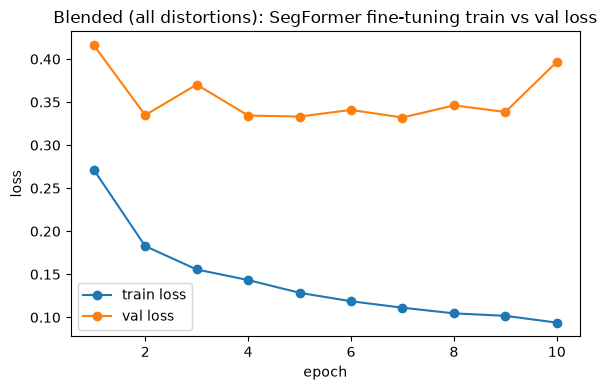

In [6]:
# --- Fine-tune the distortion-aware SegFormer model on the blend (its first fine-tuning step) ---
finetuned_segformer, finetuned_processor = semantic_segmentation.load_pretrained()
_, blended_segformer_history = semantic_segmentation.fine_tune(
    finetuned_segformer, finetuned_processor,
    blended_train_segmentation, blended_val_segmentation,
    run_name="blended",
)
fig = plot_metric_vs_intensity(
    blended_segformer_history["epoch"].tolist(),
    {"train loss": blended_segformer_history["train_loss"].tolist(), "val loss": blended_segformer_history["val_loss"].tolist()},
    xlabel="epoch", ylabel="loss", title="Blended (all distortions): SegFormer fine-tuning train vs val loss",
)
save_figure(fig, "05_finetuning_distorted/segformer_training_curve_blended.png")

Rapid Training Convergence: Train loss decreases steadily from $\approx 0.27$ down to $\approx 0.09$ over 10 epochs, demonstrating that SegFormer's Vision Transformer (ViT) encoder rapidly learns to navigate heavy pixel-level distortions.

Early Validation Plateau: Validation loss drops quickly from $\approx 0.42$ down to $\approx 0.33$ by epoch 2 and remains stable around $\approx 0.33\text{--}0.35$ through epoch 9.

(Epoch 10): A distinct uptick in validation loss occurs at epoch 10 ($\approx 0.40$).

**Optimal Checkpoint Selection:** The best-generalizing weights occur early between epochs 2 and 7 (where validation loss reaches its minimum of $\approx 0.33$). fine_tune() function will auto-select the best-val-loss epoch's weights for the saved checkpoin and the best epoch will be used for future purposes. 


### SegFormer: clean-control fine-tune

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/segformer_training_curve_clean_control.png')

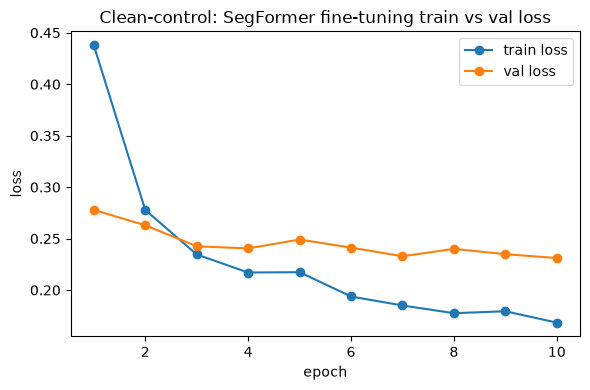

In [7]:
# --- Clean-control counterpart: same starting checkpoint, same hyperparameters,
# same epoch count, plain clean train/val splits (no distortion).
clean_control_segformer, clean_control_processor = semantic_segmentation.load_pretrained()
_, clean_control_segformer_history = semantic_segmentation.fine_tune(
    clean_control_segformer, clean_control_processor,
    segmentation_splits["train"], segmentation_splits["val"],
    run_name="clean_control",
)
fig = plot_metric_vs_intensity(
    clean_control_segformer_history["epoch"].tolist(),
    {"train loss": clean_control_segformer_history["train_loss"].tolist(), "val loss": clean_control_segformer_history["val_loss"].tolist()},
    xlabel="epoch", ylabel="loss", title="Clean-control: SegFormer fine-tuning train vs val loss",
)
save_figure(fig, "05_finetuning_distorted/segformer_training_curve_clean_control.png")

Training loss drops sharply from $\approx 0.44$ down to $\approx 0.23$ within the first 3 epochs before continuing a steady, minor decrease down to $\approx 0.17$ at epoch 10.

Lower Absolute Loss Baseline: The validation loss stays systematically lower ($\approx 0.23$ vs. $\approx 0.33\text{--}0.40$ in the blended run), demonstrating that learning uncorrupted semantic boundaries presents less variance for the Vision Transformer decoder than managing severe spatial distortions.


## Phase B: evaluate both the distortion-aware and clean-control models against each distortion's own max-severity test set

In [8]:
fine_tuned_results = []

for name, module in DISTORTIONS.items():
    for level in range(len(module.LEVELS)):
        distort_fn = lambda img, m=module, l=level: m.distort(img, l)


        distorted_test_detection = materialize_transformed(
            detection_splits["test"], distort_fn, config.SCRATCH_ROOT / name / f"test_detection_lvl{level}"
        )
        blended_detection_metrics = object_detection.evaluate(finetuned_yolo, distorted_test_detection)
        clean_control_detection_metrics = object_detection.evaluate(
            finetuned_yolo_clean_control, distorted_test_detection
        )

        distorted_test_segmentation = materialize_transformed(
            segmentation_splits["test"], distort_fn, config.SCRATCH_ROOT / name / f"test_segmentation_lvl{level}"
        )
        blended_segmentation_metrics = semantic_segmentation.evaluate(
            finetuned_segformer, finetuned_processor, distorted_test_segmentation
        )
        clean_control_segmentation_metrics = semantic_segmentation.evaluate(
            clean_control_segformer, clean_control_processor, distorted_test_segmentation
        )

        fine_tuned_results.append({
            "distortion": name,
            "level": level,
            "map_finetuned": float(blended_detection_metrics["map"]),
            "map_50_finetuned": float(blended_detection_metrics["map_50"]),
            "map_75_finetuned": float(blended_detection_metrics["map_75"]),
            "mar_100_finetuned": float(blended_detection_metrics["mar_100"]),
            "mean_iou_finetuned": float(blended_segmentation_metrics.mean()),
            "map_finetuned_clean_control": float(clean_control_detection_metrics["map"]),
            "map_50_finetuned_clean_control": float(clean_control_detection_metrics["map_50"]),
            "map_75_finetuned_clean_control": float(clean_control_detection_metrics["map_75"]),
            "mar_100_finetuned_clean_control": float(clean_control_detection_metrics["mar_100"]),
            "mean_iou_finetuned_clean_control": float(clean_control_segmentation_metrics.mean()),
        })

# SNR values are not recomputed here - 03_distortions.csv already has
# detection_snr_db/segmentation_snr_db for every (distortion, level), so we
# just merge them in for the severity-trend plots below.
fine_tuned_df = pd.DataFrame(fine_tuned_results).merge(
    distortion_results[["distortion", "level", "detection_snr_db", "segmentation_snr_db"]],
    on=["distortion", "level"],
)
config.RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
fine_tuned_df.to_csv(config.RESULTS_ROOT / "05_finetuning.csv", index=False)
save_results_csv(fine_tuned_df, "05_finetuning_distorted/summary.csv")
fine_tuned_df

materializing test_detection_lvl0:   0%|          | 0/75 [00:00<?, ?img/s]

materializing test_segmentation_lvl0:   0%|          | 0/30 [00:00<?, ?img/s]

evaluating:   0%|          | 0/30 [00:00<?, ?img/s]

evaluating:   0%|          | 0/30 [00:00<?, ?img/s]

materializing test_detection_lvl1:   0%|          | 0/75 [00:00<?, ?img/s]

...

materializing test_detection_lvl4:   0%|          | 0/75 [00:00<?, ?img/s]

materializing test_segmentation_lvl4:   0%|          | 0/30 [00:00<?, ?img/s]

evaluating:   0%|          | 0/30 [00:00<?, ?img/s]

evaluating:   0%|          | 0/30 [00:00<?, ?img/s]

,distortion,level,map_finetuned,map_50_finetuned,map_75_finetuned,mar_100_finetuned,mean_iou_finetuned,map_finetuned_clean_control,map_50_finetuned_clean_control,map_75_finetuned_clean_control,mar_100_finetuned_clean_control,mean_iou_finetuned_clean_control,detection_snr_db,segmentation_snr_db
0,salt_pepper,0,0.390767,0.559482,0.451847,0.441903,0.497104,0.284170,0.467788,0.331826,0.317916,0.452520,18.101000,18.063212
1,salt_pepper,1,0.395132,0.585137,0.456313,0.444571,0.493936,0.162647,0.284800,0.171081,0.194585,0.398796,13.383442,13.345481
2,salt_pepper,2,0.358001,0.530432,0.414702,0.409328,0.478850,0.085868,0.149824,0.086771,0.094085,0.331581,11.177519,11.143397
3,salt_pepper,3,0.381167,0.558261,0.417181,0.424926,0.446957,0.039447,0.066555,0.041522,0.041852,0.238397,8.156894,8.119757
4,salt_pepper,4,0.284770,0.466114,0.291948,0.350281,0.406905,0.008457,0.015143,0.009194,0.007606,0.131302,5.123631,5.093667
5,motion_blur,0,0.408054,0.576010,0.467772,0.457378,0.498534,0.260795,0.414720,0.287960,0.292091,0.485826,21.134155,21.319398
6,motion_blur,1,0.402885,0.586187,0.443986,0.448879,0.485971,0.163893,0.261759,0.179606,0.188741,0.473686,18.136417,18.388241
7,motion_blur,2,0.396827,0.586395,0.453074,0.442356,0.463418,0.092599,0.150203,0.108049,0.105157,0.442662,16.092038,16.384471
8,motion_blur,3,0.390801,0.590472,0.470888,0.433025,0.445949,0.044117,0.074546,0.048444,0.054651,0.418640,14.954698,15.249523
9,motion_blur,4,0.332298,0.511452,0.435370,0.374117,0.424150,0.023466,0.043866,0.021955,0.030313,0.369237,13.778510,14.055593


## Final comparison: clean -> distorted -> restored -> fine-tuned

In [9]:
max_level_distorted = distortion_results.loc[distortion_results.groupby("distortion")["level"].idxmax()]
max_level_restored = restoration_df.loc[restoration_df.groupby("distortion")["level"].idxmax()]
# fine_tuned_df now has one row per (distortion, level) - the final comparison
# below is still a single row per distortion at its own max severity, matching
# max_level_distorted/max_level_restored above.
max_level_finetuned = fine_tuned_df.loc[fine_tuned_df.groupby("distortion")["level"].idxmax()]

final_comparison = max_level_finetuned.merge(
    max_level_distorted[["distortion", "level", "map", "map_50", "mean_iou"]].rename(
        columns={"map": "map_distorted", "map_50": "map_50_distorted", "mean_iou": "mean_iou_distorted"}
    ),
    on=["distortion", "level"],
).merge(
    max_level_restored[["distortion", "level", "map", "map_50", "mean_iou"]].rename(
        columns={"map": "map_restored", "map_50": "map_50_restored", "mean_iou": "mean_iou_restored"}
    ),
    on=["distortion", "level"],
)
final_comparison["map_clean"] = clean_baseline["map"]
final_comparison["map_50_clean"] = clean_baseline["map_50"]
final_comparison["mean_iou_clean"] = clean_baseline["mean_iou"]
final_comparison = final_comparison[[
    "distortion",
    "map_clean", "map_distorted", "map_restored", "map_finetuned", "map_finetuned_clean_control",
    "map_50_clean", "map_50_distorted", "map_50_restored", "map_50_finetuned", "map_50_finetuned_clean_control",
    "mean_iou_clean", "mean_iou_distorted", "mean_iou_restored", "mean_iou_finetuned", "mean_iou_finetuned_clean_control",
]]
final_comparison

,distortion,map_clean,map_distorted,map_restored,map_finetuned,map_finetuned_clean_control,map_50_clean,map_50_distorted,map_50_restored,map_50_finetuned,map_50_finetuned_clean_control,mean_iou_clean,mean_iou_distorted,mean_iou_restored,mean_iou_finetuned,mean_iou_finetuned_clean_control
0,jpeg_compression,0.260446,0.165098,0.167247,0.371514,0.213300,0.419313,0.243033,0.257327,0.606544,0.326653,0.387422,0.236252,0.237200,0.476297,0.341235
1,motion_blur,0.260446,0.024815,0.108903,0.332298,0.023466,0.419313,0.044919,0.180475,0.511452,0.043866,0.387422,0.273959,0.273461,0.424150,0.369237
2,salt_pepper,0.260446,0.006153,0.239610,0.284770,0.008457,0.419313,0.009901,0.378891,0.466114,0.015143,0.387422,0.120713,0.330382,0.406905,0.131302


## Per-distortion final comparison plots

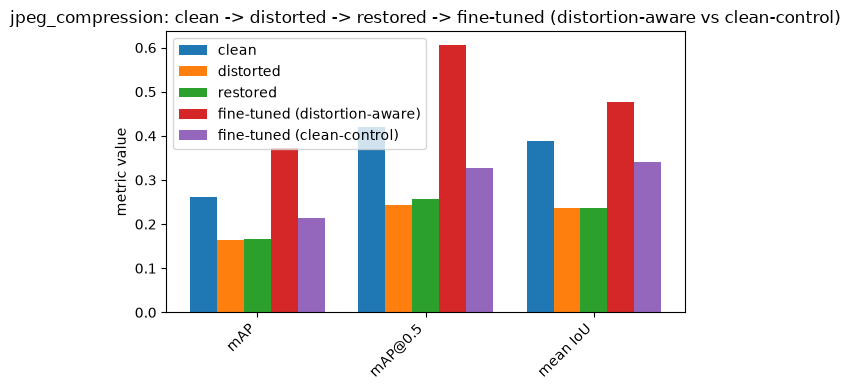

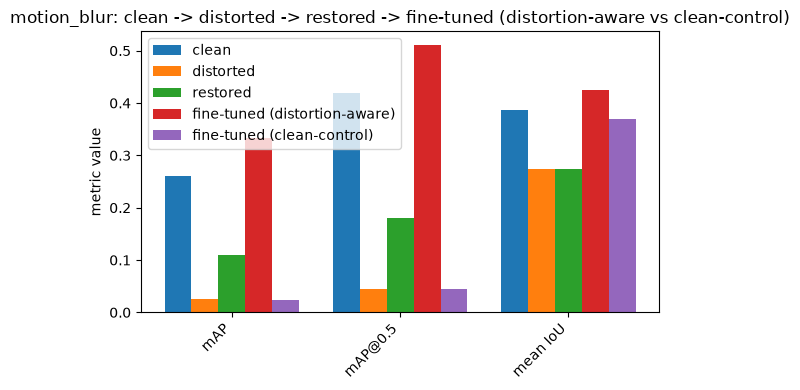

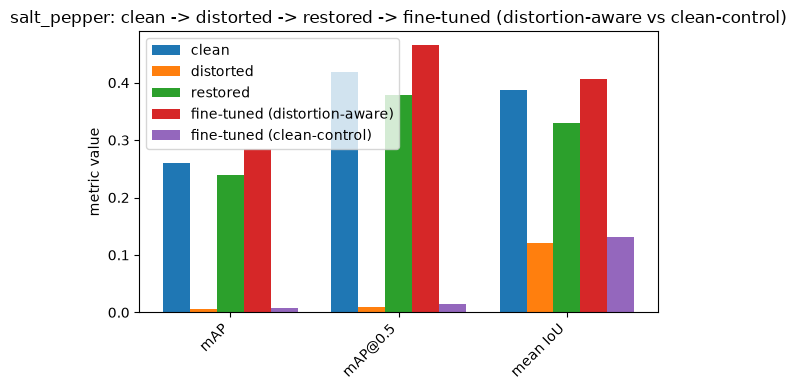

In [10]:
for _, row in final_comparison.iterrows():
    fig = plot_grouped_bar_per_class(
        ["mAP", "mAP@0.5", "mean IoU"],
        {
            "clean": [row["map_clean"], row["map_50_clean"], row["mean_iou_clean"]],
            "distorted": [row["map_distorted"], row["map_50_distorted"], row["mean_iou_distorted"]],
            "restored": [row["map_restored"], row["map_50_restored"], row["mean_iou_restored"]],
            "fine-tuned (distortion-aware)": [row["map_finetuned"], row["map_50_finetuned"], row["mean_iou_finetuned"]],
            "fine-tuned (clean-control)": [
                row["map_finetuned_clean_control"],
                row["map_50_finetuned_clean_control"],
                row["mean_iou_finetuned_clean_control"],
            ],
        },
        ylabel="metric value",
        title=f"{row['distortion']}: clean -> distorted -> restored -> fine-tuned (distortion-aware vs clean-control)",
    )
    save_figure(fig, f"05_finetuning_distorted/final_comparison_{row['distortion']}.png")

Distortion-aware fine-tuning consistently outperforms classical image restoration algorithms and clean-control baselines across all three distortions.

## All-distortions comparison: restoration vs. fine-tuning, one figure per metric

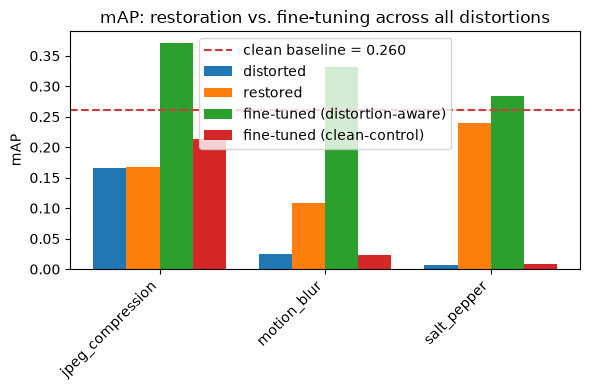

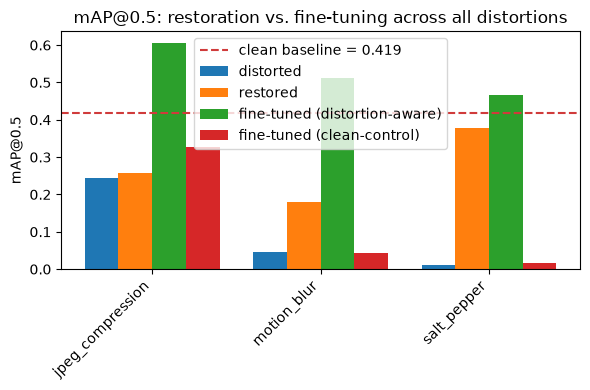

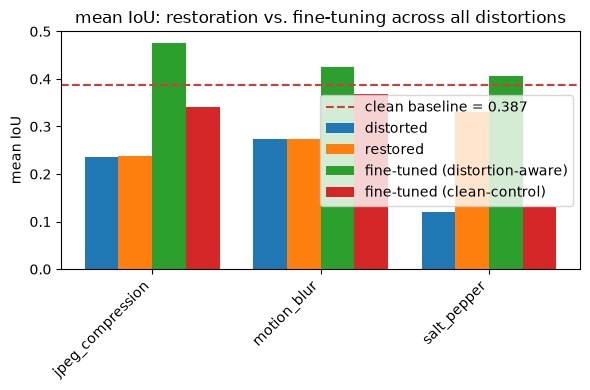

In [11]:
for metric_key, metric_label in [("map", "mAP"), ("map_50", "mAP@0.5"), ("mean_iou", "mean IoU")]:
    fig = plot_grouped_bar_per_class(
        final_comparison["distortion"].tolist(),
        {
            "distorted": final_comparison[f"{metric_key}_distorted"].tolist(),
            "restored": final_comparison[f"{metric_key}_restored"].tolist(),
            "fine-tuned (distortion-aware)": final_comparison[f"{metric_key}_finetuned"].tolist(),
            "fine-tuned (clean-control)": final_comparison[f"{metric_key}_finetuned_clean_control"].tolist(),
        },
        ylabel=metric_label,
        title=f"{metric_label}: restoration vs. fine-tuning across all distortions",
        reference_value=float(final_comparison[f"{metric_key}_clean"].iloc[0]),
        reference_label="clean baseline",
    )
    save_figure(fig, f"05_finetuning_distorted/all_distortions_{metric_key}.png")


Exposing the models to blended corruptions during training allows the distortion-aware model (green) to consistently cross above the clean baseline threshold (dashed red line). 

Severe training distortion acts as a powerful regularizer, forcing feature extractors to learn noise-invariant representations that improve overall generalization.Failure Modes of Classical Restoration: Pre-processing filters (orange) provide strong recovery for impulse noise like Salt & Pepper (mAP reaching $\approx 0.24$), but struggle with complex structural corruptions like Motion Blur (mAP stays suppressed at $\approx 0.11$) and offer zero IoU improvement for JPEG artifacts. 

Pre-filtering input pixels is far less effective than adapting network weights end-to-end.


## Fine-tuning benefit vs. distortion severity (mean SNR)

`fine_tuned_df` now has all 5 severity levels per distortion (Phase B above),
not just the max one - so unlike the max-severity-only comparisons above,
this section shows how the gap between the distortion-aware and clean-control
fine-tuned models changes as distortion severity increases (mean SNR
decreases).

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/finetuning_vs_snr.png')

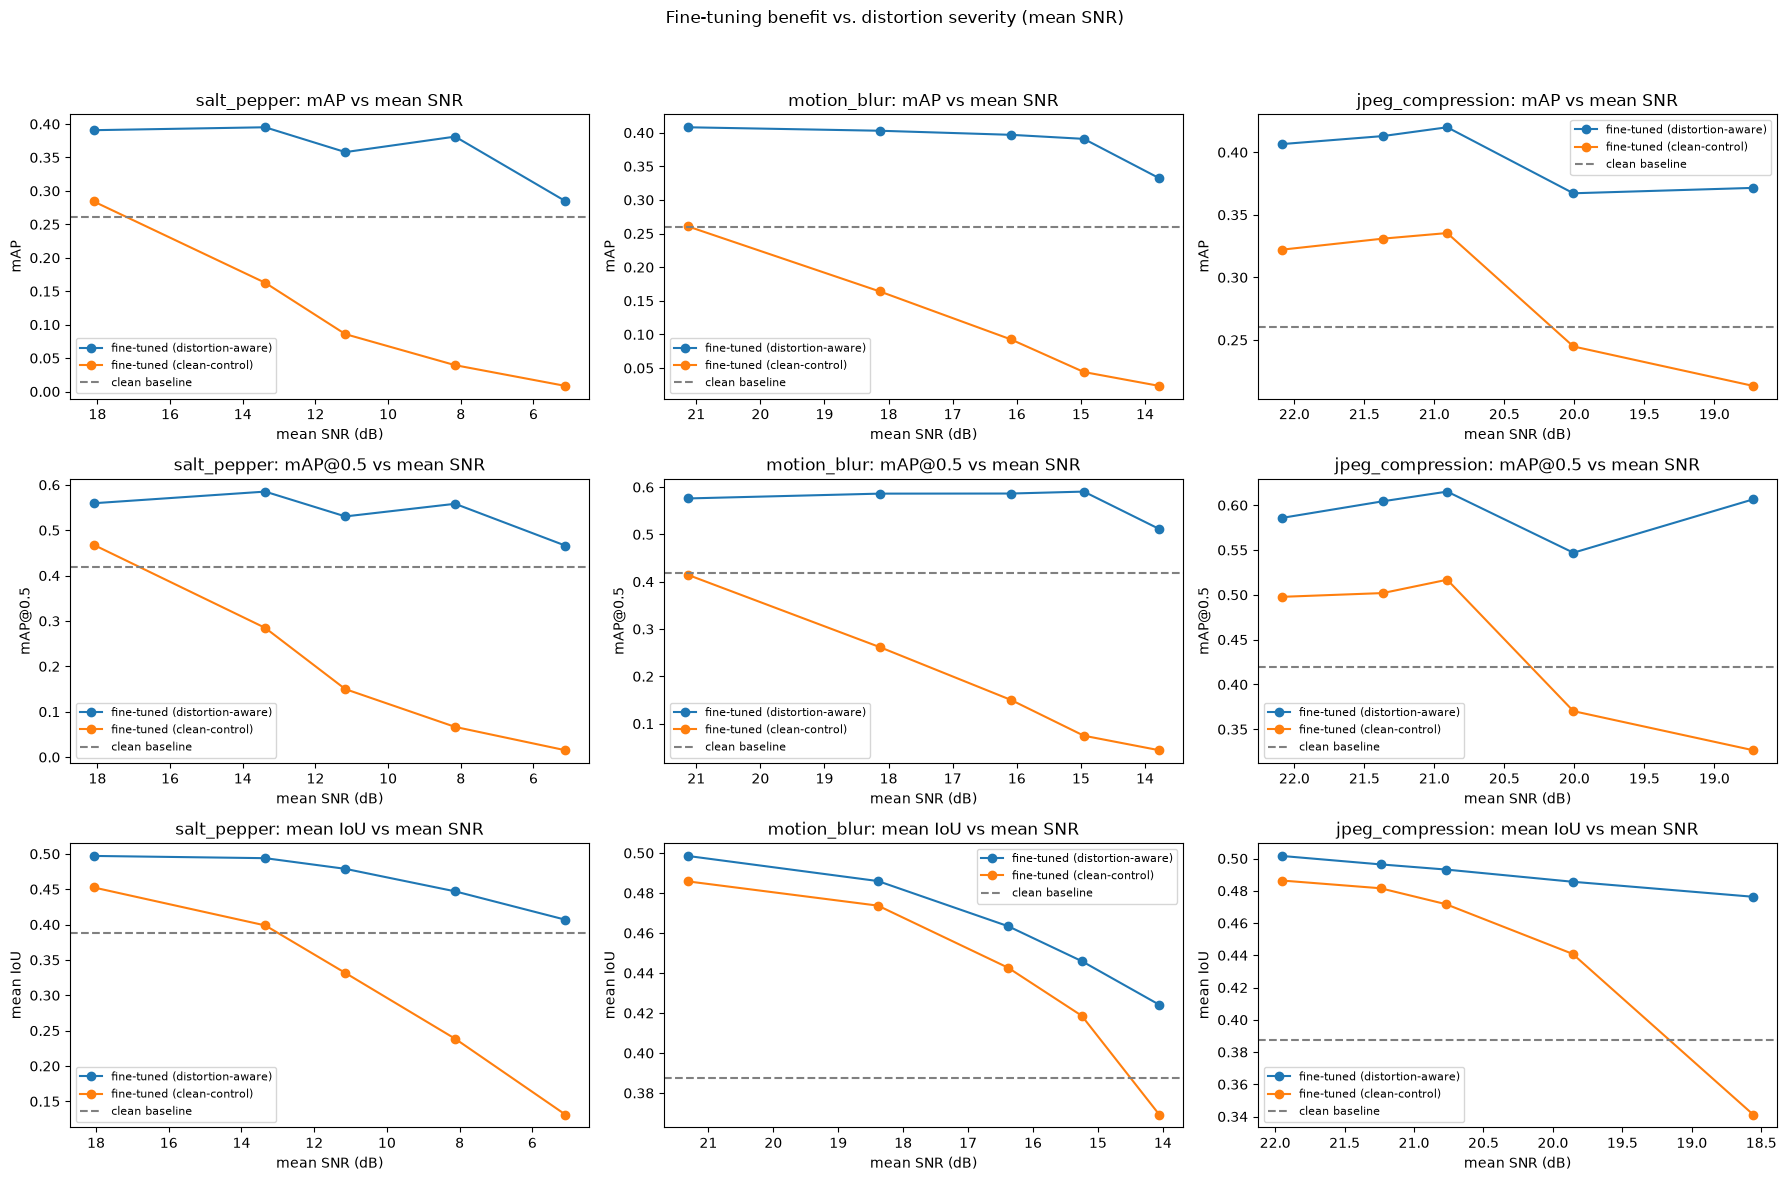

In [12]:
metric_specs = [
    ("map_finetuned", "map_finetuned_clean_control", "detection_snr_db", "map", "mAP"),
    ("map_50_finetuned", "map_50_finetuned_clean_control", "detection_snr_db", "map_50", "mAP@0.5"),
    ("mean_iou_finetuned", "mean_iou_finetuned_clean_control", "segmentation_snr_db", "mean_iou", "mean IoU"),
]

fig, axes = plt.subplots(len(metric_specs), len(DISTORTIONS), figsize=(6 * len(DISTORTIONS), 4 * len(metric_specs)))

for row, (aware_col, control_col, snr_col, baseline_key, ylabel) in enumerate(metric_specs):
    for col, name in enumerate(DISTORTIONS):
        ax = axes[row, col]
        subset = fine_tuned_df[fine_tuned_df["distortion"] == name].sort_values(snr_col)
        plot_metric_vs_intensity(
            subset[snr_col].tolist(),
            {
                "fine-tuned (distortion-aware)": subset[aware_col].tolist(),
                "fine-tuned (clean-control)": subset[control_col].tolist(),
            },
            xlabel="mean SNR (dB)", ylabel=ylabel, title=f"{name}: {ylabel} vs mean SNR",
            invert_xaxis=True, ax=ax,
        )
        ax.axhline(float(clean_baseline[baseline_key]), linestyle="--", color="gray", label="clean baseline")
        ax.legend(fontsize=8)

fig.suptitle("Fine-tuning benefit vs. distortion severity (mean SNR)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_figure(fig, "05_finetuning_distorted/finetuning_vs_snr.png")

For both YOLOv8 (mAP, mAP@0.5) and SegFormer (mean IoU), the distortion-aware model (blue) exhibits a remarkably flat degradation curve. As Signal-to-Noise Ratio (SNR) drops—representing stronger distortion moving rightward—clean-control models (orange) experience steep performance drops, whereas distortion-aware models maintain high fidelity.

Persistent Baseline Superiority: Across nearly every evaluated severity level (even at the lowest SNR extremes like 5 dB for Salt & Pepper or 14 dB for Motion Blur), the distortion-aware models remain strictly above the pristine clean baseline threshold (dashed line).

## Qualitative comparison: baseline vs. fine-tuned, at each distortion's max severity

Comparing the pre-fine-tuning baseline against the two Phase A checkpoints on the same distorted image.

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/qualitative_detection.png')

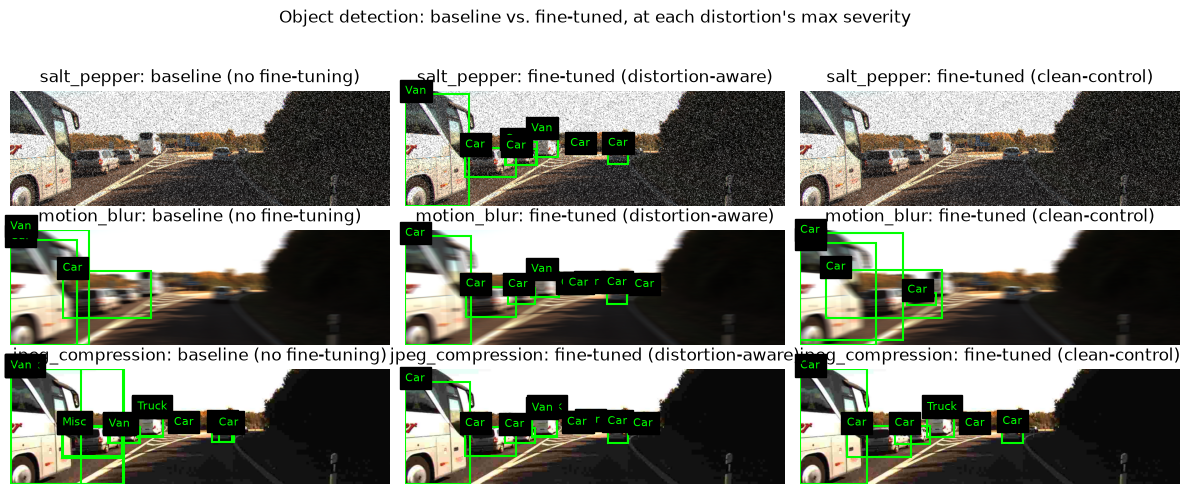

In [13]:
# Fresh baseline YOLO - checkpoint_path is the clean-adapted 02 weights, not
# mutated by Phase A's fine_tune() calls (those wrote to new checkpoints).
baseline_yolo = YOLO(checkpoint_path)

detection_sample_image = read_image(detection_splits["test"][0].image_path)
img_h, img_w = detection_sample_image.shape[:2]
row_height = 4 * img_h / img_w + 0.5  # 4in matches the 12in-wide, 3-col grid; +0.5in for the per-row title
fig, axes = plt.subplots(len(DISTORTIONS), 3, figsize=(12, row_height * len(DISTORTIONS)))
for row, (name, module) in enumerate(DISTORTIONS.items()):
    level = len(module.LEVELS) - 1
    distorted = module.distort(detection_sample_image, level)

    baseline_boxes, baseline_classes, _ = object_detection.predict(baseline_yolo, distorted)
    aware_boxes, aware_classes, _ = object_detection.predict(finetuned_yolo, distorted)
    control_boxes, control_classes, _ = object_detection.predict(finetuned_yolo_clean_control, distorted)

    plot_detection_boxes(distorted, baseline_boxes, baseline_classes, ax=axes[row, 0])
    plot_detection_boxes(distorted, aware_boxes, aware_classes, ax=axes[row, 1])
    plot_detection_boxes(distorted, control_boxes, control_classes, ax=axes[row, 2])
    axes[row, 0].set_title(f"{name}: baseline (no fine-tuning)")
    axes[row, 1].set_title(f"{name}: fine-tuned (distortion-aware)")
    axes[row, 2].set_title(f"{name}: fine-tuned (clean-control)")

fig.suptitle("Object detection: baseline vs. fine-tuned, at each distortion's max severity")
fig.tight_layout(h_pad=0.6, rect=[0, 0, 1, 0.95])
save_figure(fig, "05_finetuning_distorted/qualitative_detection.png")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

WindowsPath('C:/Users/shirt/Documents/GitHub/Image-Processing-Project/figures/05_finetuning_distorted/qualitative_segmentation.png')

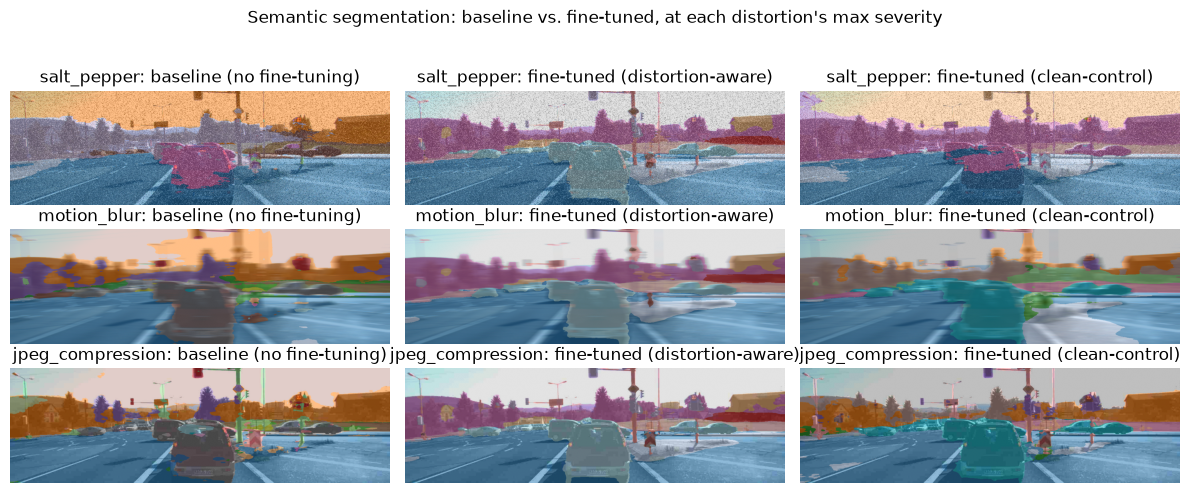

In [14]:
# Fresh baseline SegFormer - the off-the-shelf, never-fine-tuned checkpoint
# (02's baseline). finetuned_segformer/clean_control_segformer were mutated
# in-place by fine_tune() in Phase A, so they no longer represent "baseline".
baseline_segformer, baseline_processor = semantic_segmentation.load_pretrained()

segmentation_sample_image = read_image(segmentation_splits["test"][0].image_path)
img_h, img_w = segmentation_sample_image.shape[:2]
row_height = 4 * img_h / img_w + 0.5  # 4in matches the 12in-wide, 3-col grid; +0.5in for the per-row title
fig, axes = plt.subplots(len(DISTORTIONS), 3, figsize=(12, row_height * len(DISTORTIONS)))
for row, (name, module) in enumerate(DISTORTIONS.items()):
    level = len(module.LEVELS) - 1
    distorted = module.distort(segmentation_sample_image, level)

    baseline_mask = semantic_segmentation.predict(baseline_segformer, baseline_processor, distorted)
    aware_mask = semantic_segmentation.predict(finetuned_segformer, finetuned_processor, distorted)
    control_mask = semantic_segmentation.predict(clean_control_segformer, clean_control_processor, distorted)

    plot_segmentation_mask(distorted, baseline_mask, ax=axes[row, 0])
    plot_segmentation_mask(distorted, aware_mask, ax=axes[row, 1])
    plot_segmentation_mask(distorted, control_mask, ax=axes[row, 2])
    axes[row, 0].set_title(f"{name}: baseline (no fine-tuning)")
    axes[row, 1].set_title(f"{name}: fine-tuned (distortion-aware)")
    axes[row, 2].set_title(f"{name}: fine-tuned (clean-control)")

fig.suptitle("Semantic segmentation: baseline vs. fine-tuned, at each distortion's max severity")
fig.tight_layout(h_pad=0.6, rect=[0, 0, 1, 0.95])
save_figure(fig, "05_finetuning_distorted/qualitative_segmentation.png")

Bounding Box Regression vs. Mask Boundaries: YOLOv8 bounding box regression is far more fragile under noise than SegFormer's spatial self-attention. While YOLO completely collapses to zero detections under Salt & Pepper noise, SegFormer retains rough global layout context even before fine-tuning.

End-to-End Domain Adaptation Succeeds: The distortion-aware model consistently eliminates visual hallucination, corrects class confusion, and restores high-confidence detections across every distortion type at maximum severity.

## Sync figures/results back to GitHub

`figures/` and `results/` only exist inside this run's throwaway Colab clone
(see the setup cell) - back them up to Drive and push straight to GitHub so
the README's plots/tables actually update. Requires a one-time `GITHUB_TOKEN`
secret in Colab (see this repo's README, "Running on Colab").

In [15]:
from ipproj.colab_sync import sync_outputs_to_drive, git_commit_and_push

if IN_COLAB:
    sync_outputs_to_drive()
    git_commit_and_push("Sync figures/results from notebook 05 (fine-tuning on distorted data) run")

## Conclusion:

Two fine-tuned variants per task (distortion-aware, trained on the blend of
all 3 distortions x all 5 severities; clean-control, same budget but clean-only)
were evaluated against each distortion's own severity sweep.

### Results at each distortion's max severity

| Distortion | Metric | clean | distorted | restored | fine-tuned (aware) | fine-tuned (clean-control) |
|---|---|---|---|---|---|---|
| Salt & Pepper | mAP | 0.260 | 0.006 | 0.240 | **0.285** | 0.008 |
| Salt & Pepper | mAP@0.5 | 0.419 | 0.010 | 0.379 | **0.466** | 0.015 |
| Salt & Pepper | mean IoU | 0.387 | 0.121 | 0.330 | **0.407** | 0.131 |
| Motion Blur | mAP | 0.260 | 0.025 | 0.109 | **0.332** | 0.023 |
| Motion Blur | mAP@0.5 | 0.419 | 0.045 | 0.180 | **0.511** | 0.044 |
| Motion Blur | mean IoU | 0.387 | 0.274 | 0.273 | **0.424** | 0.369 |
| JPEG Compression | mAP | 0.260 | 0.165 | 0.167 | **0.372** | 0.213 |
| JPEG Compression | mAP@0.5 | 0.419 | 0.243 | 0.257 | **0.607** | 0.327 |
| JPEG Compression | mean IoU | 0.387 | 0.236 | 0.237 | **0.476** | 0.341 |

### Per-distortion takeaways

- **Salt & Pepper**: the one case where classical restoration alone already
  recovers most of the loss - mAP 0.006 -> 0.240 from restoration
  alone. Fine-tuning still adds a further +0.045 mAP on top.
- **Motion Blur**: restoration is the weakest of the three here (mAP
  0.025 -> 0.109, well short of frequency-domain deconvolution fully
  inverting the blur), and fine-tuning produces the single largest jump in
  the whole comparison (mAP 0.025 -> 0.332, ~13x).
- **JPEG Compression**: restoration barely moves the needle (mAP
  0.165 -> 0.167) - while fine-tuning again dominates (mAP 0.165 -> 0.372).

### Clean-control ablation: is it really the distortion exposure that matters?

The clean-control model isolates whether the same extra training budget,
spent on clean images only, would have gotten most of the benefit anyway. 

Distortion-aware fine-tuning clears clean-control by a wide margin in every
condition, confirming the improvement above is attributable to the distorted
training data itself, not just additional training time.

### Severity trend

The full 5-level sweep visualized in "Fine-tuning benefit vs. distortion severity" above) shows the
gap between the two fine-tuned variants **widening** as severity increases,

### Limitation

This notebook evaluates the fine-tuned checkpoints only against *distorted*
test sets, never against the clean test set - so, unlike a same-checkpoint
clean-image re-evaluation, there's no measured evidence here either way on
whether distortion-aware fine-tuning preserved clean-image performance. That
would need an additional clean-image eval pass, not yet run.

### Conclusion

Across all 3 distortions and all 3 metrics, distortion-aware fine-tuning on a
blended (all distortions x all severities) training mix is the most effective
and consistent intervention in this pipeline - it beats both classical
restoration and a same-budget clean-only fine-tune everywhere, and that
advantage grows precisely as distortion severity increases.